# Смирнов Сергей ФПэ-01-22

## Домашняя работа
Построить графики зависимостией $\varphi(\varepsilon)$, $\eta_i(\varepsilon)$, $H(\varepsilon)$, для $\eta_т$=0.88, $\eta_к$ = 0.85, при различных значениях температуры перед газовой турбиной $T_c$ и температурой воздуха перед компрессором $t_a=0$ C. m = 0.25, $\delta == \varepsilon$, $\eta_{кс}$ = 1. 

$t_c$ = 400, 500, 600, 700, 800, 900, 1200, 1400 C

In [23]:
import numpy as np
import matplotlib.pyplot as plt 

to_kelvin = lambda x: x + 273.15

In [24]:
class Point():

    def __init__(self,fi,eff,ht,hk):
        self.fi = fi
        self.eff = eff
        self.ht = ht
        self.hk = hk
        
    def fi(self):return self.fi
    def eff(self):return self.eff
    def ht(self):return self.ht
    def hk(self):return self.hk
    @property
    def H(self):
        H = self.fi * self.ht/10**6
        return H

    @property
    def dictt(self):
        dct = {"fi": self.fi, "eff":self.eff, "ht": self.ht,"hk":self.hk}
        return dct

In [25]:
Cp_air = 1007
Cp_gas = 1225
Cp = (Cp_air + Cp_gas) / 2
m = 0.25
turbine_efficiency = 0.88
compressor_efficiency = 0.85
combustor_efficiency = 1
T_a = to_kelvin(0)
T_c = [500, 600, 700, 800, 900, 1200, 1400]
T_c_str = []
for i in range(len(T_c)):
    T_c[i] = to_kelvin(T_c[i])
    T_c_str.append("Tc = " + str(T_c[i]) +" K")

In [26]:
def calc_psihH(T_c,eps,T_a,Cp,Cp_air,turbine_efficiency,compressor_efficiency,combustor_efficiency):
        tau = to_kelvin(T_c) / T_a
        delta = eps
        H_t = Cp * T_c * (1 - delta ** (-m)) * turbine_efficiency
        H_k = Cp * T_a * ((eps ** m) - 1) / compressor_efficiency
        T_b = T_a +(H_k / Cp_air)
        q_comb = Cp * (T_c - T_b) * (1 / combustor_efficiency)
        efficiency = (H_t - H_k) / q_comb
        num = eps ** m
        denum = tau * turbine_efficiency * compressor_efficiency
        work_coefficient = 1 - num/denum
        pnt = Point(work_coefficient, efficiency, H_t, H_k)
        return pnt
    
def paint(var_list, T_c):
    for i in range(0,len(var_list)):
        plt.plot(var_list[i])
    plt.legend((T_c_str))  

In [27]:
fii = []
effi = []
H = []
for i in range(len(T_c)):
    fi = []
    eff = []
    h = []
    for eps in range(1,20):
        point = calc_psihH(T_c[i],eps,T_a,Cp,Cp_air,turbine_efficiency,compressor_efficiency,combustor_efficiency)
        fi.append(point.fi)
        eff.append(point.eff)
        h.append(point.H)
    H.append(h)
    effi.append(eff)
    fii.append(fi)

<>:3: SyntaxWarning: invalid escape sequence '\e'
<>:3: SyntaxWarning: invalid escape sequence '\e'
C:\Users\Vait_\AppData\Local\Temp\ipykernel_19024\3558383340.py:3: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\epsilon$')


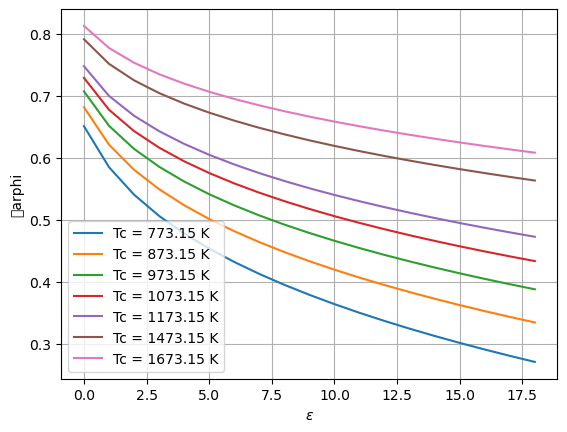

In [32]:
paint(fii,T_c_str)            
plt.ylabel('\varphi')
plt.xlabel('$\epsilon$') 
plt.grid(True)
plt.show()

<>:2: SyntaxWarning: invalid escape sequence '\e'
<>:3: SyntaxWarning: invalid escape sequence '\e'
<>:2: SyntaxWarning: invalid escape sequence '\e'
<>:3: SyntaxWarning: invalid escape sequence '\e'
C:\Users\Vait_\AppData\Local\Temp\ipykernel_19024\2379603113.py:2: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel('$\eta$')
C:\Users\Vait_\AppData\Local\Temp\ipykernel_19024\2379603113.py:3: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\epsilon$')


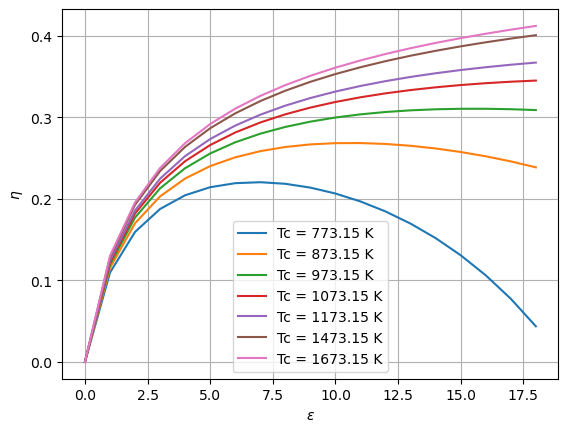

In [33]:
paint(effi,T_c_str)            
plt.ylabel('$\eta$')
plt.xlabel('$\epsilon$')
plt.grid(True)
plt.show()

<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\e'
C:\Users\Vait_\AppData\Local\Temp\ipykernel_19024\4189596777.py:4: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\epsilon$')


Text(0.5, 0, '$\\epsilon$')

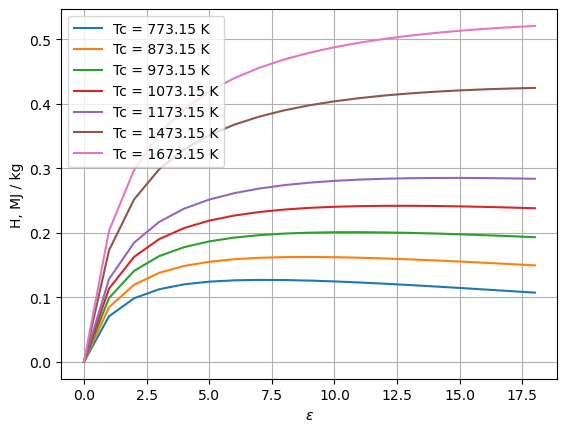

In [34]:
paint(H,T_c_str)
plt.ylabel('H, MJ / kg')
plt.grid(True)
plt.xlabel('$\epsilon$')

Найти оптимум по мощности и по КПД для температуры $t_c$ = 1200 и построить на графиках в этих точках вертикальную линию (или поставить заметную точку на соответствующей кривой)

In [35]:
tc = T_c[5]
eff = []
eps1 = []
h = []
for eps in range(1,100):
        point = calc_psihH(tc,eps,T_a,Cp,Cp_air,turbine_efficiency,compressor_efficiency,combustor_efficiency)
        eff.append(point.eff)
        eps1.append(eps)
        h.append(point.H)

66
22


<>:11: SyntaxWarning: invalid escape sequence '\e'
<>:12: SyntaxWarning: invalid escape sequence '\e'
<>:11: SyntaxWarning: invalid escape sequence '\e'
<>:12: SyntaxWarning: invalid escape sequence '\e'
C:\Users\Vait_\AppData\Local\Temp\ipykernel_19024\2729486848.py:11: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel("$H, MJ/kg, \eta$")
C:\Users\Vait_\AppData\Local\Temp\ipykernel_19024\2729486848.py:12: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\epsilon$')


Text(0.5, 0, '$\\epsilon$')

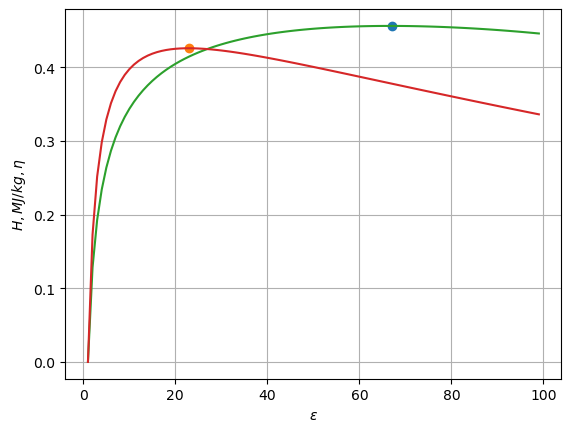

In [37]:
plt.grid(True)
a = np.argmax(eff)
b = np.argmax(h)
print(a)
print(b)

plt.plot(eps1[a], eff[a], 'o')
plt.plot(eps1[b], h[b], 'o')
plt.plot(eps1,eff)
plt.plot(eps1,h)
plt.ylabel("$H, MJ/kg, \eta$")
plt.xlabel('$\epsilon$')